<a href="https://colab.research.google.com/github/CamFuenzalidaC/GuerrerosZ/blob/main/Segunda_evaluacion_CORREGIDA_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/CamFuenzalidaC/GuerrerosZ/blob/david_dev/Segunda%20_evaluacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Nombre de integrantes: David Salvatierra Y Camilo Fuenzalida
seccion:003D

FUENTE DE INFORMACION: https://www.kaggle.com/datasets/anbudanadithya/spotify-music?resource=download

Contexto :  Spotify se ha posicionado como una de las aplicaciones de streaming más utilizadas a nivel mundial, recopilando millones de datos sobre canciones, artistas, géneros musicales y preferencias de los usuarios.

Gracias a esta gran cantidad de información, es posible aplicar técnicas de análisis de datos y Machine Learning para descubrir patrones ocultos dentro de la música. Variables como la popularidad de una canción, su energía, ritmo, duración, nivel acústico o danceability permiten estudiar qué características influyen en el éxito musical o cómo se relacionan los distintos géneros entre sí.

En esta investigación se tratara con un conjunto de datos de Spotify que contiene información de aproximadamente 114.000 canciones, incluyendo atributos musicales y datos relevantes como nombre del artista, álbum, género y nivel de popularidad.

El objetivo principal será analizar este dataset para :

Clasificar la energia de la cancion con el volumen de la misma ,
Poder detectar la acustica del genero y ver cual es el mas acustico
Ver la relacion entres intrumental y el volumen del genero.
Enetrenar modelos predictivos en base a la popularidad de la cancion




In [ ]:

# Pandas: manipulación y análisis de datos
# NumPy: operaciones matemáticas y arreglos numéricos
# Matplotlib: creación de gráficos
# Seaborn: visualizaciones estadísticas avanzadas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

In [ ]:
# Para ver todas las columnas sin cortes
pd.set_option('display.max_columns', None)

# Para ver todas las filas
pd.set_option('display.max_rows', None)

In [ ]:
url = "https://raw.githubusercontent.com/CamFuenzalidaC/GuerrerosZ/ce340033c05f2b38c72ffdbfad7d39d310892e07/Spotify_Music.csv"
df = pd.read_csv(url,index_col=0)

In [ ]:
df.head(5)#Visualizamos las primeras 5 filas del dataset para realizar una exploración inicial

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [ ]:
df.tail(5) #Visualizamos las 5 ultimas filas del dataset para realizar una exploración inicial

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.235,5,-16.393,1,0.0422,0.640,0.928,0.0863,0.0339,125.995,5,world-music
113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.117,0,-18.318,0,0.0401,0.994,0.976,0.1050,0.0350,85.239,4,world-music
113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.329,0,-10.895,0,0.0420,0.867,0.000,0.0839,0.7430,132.378,4,world-music
113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.506,7,-10.889,1,0.0297,0.381,0.000,0.2700,0.4130,135.960,4,world-music
113999,2hETkH7cOfqmz3LqZDHZf5,Cesária Evora,Miss Perfumado,Barbincor,22,241826,False,0.526,0.487,1,-10.204,0,0.0725,0.681,0.000,0.0893,0.7080,79.198,4,world-music


Se visualizan las primeras filas del dataset con el objetivo de comprender la estructura de los datos, identificar los nombres de las columnas y analizar el tipo de información contenida en cada una. Esta exploración inicial permite obtener una mejor comprensión del conjunto de datos antes de realizar análisis más avanzados.

In [ ]:
df = df.drop(columns=['track_id']) # eliminamos el tack id ya que no reprensenta  una utilidad en nuestro data set

In [ ]:
df.head(5)

,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [ ]:
df.shape # Visualizamos las dimensiones del dataset (filas y columnas) asi conoceremos el tamaño del data set

(114000, 19)

El dataset contiene 114.000 filas y 19 columnas, lo que indica que se trata de un conjunto de datos amplio y con una cantidad significativa de información. Esto permite realizar análisis estadísticos más completos y aplicar técnicas de machine learning en etapas posteriores del proyecto.

In [ ]:
df.columns #mostramos los nombres de las columnas

Index(['artists', 'album_name', 'track_name', 'popularity', 'duration_ms',
       'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode',
       'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'time_signature', 'track_genre'],
      dtype='str')

MAPEO DE DATOS:

track_id: Categórico Nominal

artists: Categórico Nominal

album_name: Categórico Nominal

track_name: Categórico Nominal

popularity: Numérico Discreto

duration_ms: Numérico Discreto

explicit: Categórico Binario

danceability: Numérico Continuo

energy: Numérico Continuo

key: Categórico Ordinal

loudness: Numérico Continuo

mode: Categórico Binario

speechiness: Numérico Continuo

acousticness: Numérico Continuo

instrumentalness: Numérico Continuo

liveness: Numérico Continuo

valence: Numérico Continuo

tempo: Numérico Continuo

time_signature: Numérico Discreto

track_genre: Categórico Nominal

Clasificación de Variables

Categórico Nominal: Categorías sin un orden o jerarquía específica.
Ejemplo: artista, nombre del álbum, género musical.

Categórico Ordinal: Categorías que siguen un orden lógico o escala.
Ejemplo: tonalidad musical representada por notas (C, D, E, F, G, A, B).

Categórico Binario: Variable con solo dos categorías posibles.
Ejemplo: explícita (Sí/No), modo musical (Mayor/Menor).

Numérico Discreto: Valores que surgen de un conteo o se expresan en números enteros.
Ejemplo: popularidad, duración en milisegundos, compás musical.

Numérico Continuo: Valores que resultan de una medición y pueden tener decimales infinitos.
Ejemplo: energía, tempo, loudness, danceability.

In [ ]:
# Contamos la cantidad de canciones por cada género musical presente en el dataset
cant_cat_genero = df['track_genre'].value_counts()

print(cant_cat_genero)

# Mostramos la cantidad total de géneros únicos disponibles
print(f"Cantidad de géneros: {cant_cat_genero.count()}")

track_genre
acoustic             1000
afrobeat             1000
alt-rock             1000
alternative          1000
ambient              1000
anime                1000
black-metal          1000
bluegrass            1000
blues                1000
brazil               1000
breakbeat            1000
british              1000
cantopop             1000
chicago-house        1000
children             1000
chill                1000
classical            1000
club                 1000
comedy               1000
country              1000
dance                1000
dancehall            1000
death-metal          1000
deep-house           1000
detroit-techno       1000
disco                1000
disney               1000
drum-and-bass        1000
dub                  1000
dubstep              1000
edm                  1000
electro              1000
electronic           1000
emo                  1000
folk                 1000
forro                1000
french               1000
funk                 1000


La variable `track_genre` contiene 114 categorías diferentes de géneros musicales, lo que refleja una amplia diversidad de estilos presentes en el dataset.

In [ ]:
# Calculamos la frecuencia de aparición de cada artista en el dataset
cant_cat_artists = df['artists'].value_counts()

# Mostramos los 50 artistas con mayor cantidad de registros
print(cant_cat_artists.head(50))

# Mostramos la cantidad total de artistas únicos presentes en el dataset
print(f"Cantidad de artistas únicos: {cant_cat_artists.count()}")

artists
The Beatles                       279
George Jones                      271
Stevie Wonder                     236
Linkin Park                       224
Ella Fitzgerald                   222
Prateek Kuhad                     217
Feid                              202
Chuck Berry                       190
Håkan Hellström                   183
OneRepublic                       181
The Beach Boys                    176
my little airport                 171
Charlie Brown Jr.                 169
Elvis Presley                     169
Red Hot Chili Peppers             159
Bryan Adams                       157
Scooter                           155
Daddy Yankee                      154
Arctic Monkeys                    152
BTS                               151
Norah Jones                       150
The Prophet                       145
Hank Williams                     140
Glee Cast                         139
Don Omar                          137
Vybz Kartel                       128
Los 

La variable `artists` presenta una gran cantidad de categorías únicas. Por esta razón, se mostrarán únicamente los 50 artistas con mayor frecuencia dentro del dataset para facilitar el análisis y la visualización de los resultados.

In [ ]:
# Revisamos los tipos de datos de cada columna del dataset
df.dtypes

artists                 str
album_name              str
track_name              str
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre             str
dtype: object

Mediante df.dtypes se observan los tipos de datos de cada columna, lo que permite clasificar las variables y preparar correctamente el análisis de datos.

In [ ]:
# Contamos la cantidad de valores nulos presentes en cada columna del dataset
df.isna().sum()

artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [ ]:
# Mostramos las filas que contienen al menos un valor nulo dentro del dataset
df[df.isnull().any(axis=1)]

,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
65900,NaN,NaN,NaN,0,0,False,0.501,0.583,7,-9.46,0,0.0605,0.69,0.00396,0.0747,0.734,138.391,4,k-pop


Se identifican los valores nulos presentes en el dataset con el fin de evaluar la calidad de los datos. Este proceso permite determinar si es necesario aplicar técnicas de limpieza y tratamiento de datos para evitar posibles errores o sesgos durante el análisis.

In [ ]:
# Eliminamos las filas que contienen valores nulos
# para trabajar con un dataset más limpio y consistente

df = df.dropna()

In [ ]:
df.isna().sum()

artists             0
album_name          0
track_name          0
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

Se procede a la limpieza del dataset eliminando los valores nulos. Esto permite trabajar con datos completos y confiables, evitando inconsistencias en los resultados del análisis.

In [ ]:
#veremos los tipos de datos, los nulos (no deberia haber nigun nulo)
#y los  valores unicos tambien los tipos de valores que puede tener ya sea
#categoricos o numericos
import pandas as pd

def tipo_analitico(col):
    if pd.api.types.is_numeric_dtype(col):
        return 'Numerico'
    else:
        return 'Categorico'

summary = pd.DataFrame({
    'tipo_dato': df.dtypes,
    'nulos': df.isnull().sum(),
    'n_unicos': df.nunique(),
    'tipo_analitico': df.apply(tipo_analitico)
})

summary

,tipo_dato,nulos,n_unicos,tipo_analitico
artists,str,0,31437,Categorico
album_name,str,0,46589,Categorico
track_name,str,0,73608,Categorico
popularity,int64,0,101,Numerico
duration_ms,int64,0,50696,Numerico
explicit,bool,0,2,Numerico
danceability,float64,0,1174,Numerico
energy,float64,0,2083,Numerico
key,int64,0,12,Numerico
loudness,float64,0,19480,Numerico


In [ ]:
# Obtenemos un resumen estadístico de las variables numéricas,
# incluyendo promedio, desviación estándar, valores mínimos y máximos, podemos ver los posibles valores atipicos
df.describe()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,113999.000000,1.139990e+05,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000
mean,33.238827,2.280312e+05,0.566801,0.641383,5.309126,-8.258950,0.637558,0.084652,0.314907,0.156051,0.213554,0.474066,122.147695,3.904034
std,22.304959,1.072961e+05,0.173543,0.251530,3.559999,5.029357,0.480708,0.105733,0.332522,0.309556,0.190378,0.259261,29.978290,0.432623
min,0.000000,8.586000e+03,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218500,4.000000
50%,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.597500,0.049000,0.273000,0.683000,140.071000,4.000000
max,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [ ]:
# La librería `category_encoders` permite convertir variables categóricas en representaciones numéricas, facilitando su uso en algoritmos de análisis de datos y machine learning.
!pip install category_encoders

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

In [ ]:
from sklearn.preprocessing import OneHotEncoder
import category_encoders as ce
import pandas as pd

# La columna 'explicit' es booleana (True/False) y no pasa por ningun encoder
# de las librerias que usamos (OneHotEncoder / BinaryEncoder), por lo que
# se queda como bool y nunca llega a df_final como variable numerica real.
# La convertimos manualmente a 0/1 para que quede 100% numerica, igual que 'mode'.
df['explicit'] = df['explicit'].astype(int)

# Aplicamos One-Hot Encoding a la variable track_genre
# ya que sus categorías no poseen un orden específico
ohe = OneHotEncoder(sparse_output=False)
genre_encoded = ohe.fit_transform(df[['track_genre']])

genre_df = pd.DataFrame(
    genre_encoded,
    columns=ohe.get_feature_names_out(['track_genre']),
    index=df.index
)

# Aplicamos Binary Encoding a la variable artists
# para reducir la cantidad de columnas generadas
be = ce.BinaryEncoder(cols=['artists'])
artists_binary = be.fit_transform(df[['artists']])

# Unimos las nuevas variables codificadas y eliminamos columnas innecesarias
cols_to_drop = ['artists', 'track_name', 'album_name', 'track_genre']

df_final = pd.concat(
    [df.drop(columns=cols_to_drop), genre_df, artists_binary],
    axis=1
)

# Visualizamos el nuevo dataset
print(df_final.head())
print(f"Total de columnas finales: {len(df_final.columns)}")

   popularity  duration_ms  explicit  danceability  energy  key  loudness  \
0          73       230666         0         0.676  0.4610    1    -6.746   
1          55       149610         0         0.420  0.1660    1   -17.235   
2          57       210826         0         0.438  0.3590    0    -9.734   
3          71       201933         0         0.266  0.0596    0   -18.515   
4          82       198853         0         0.618  0.4430    2    -9.681   

   mode  speechiness  acousticness  instrumentalness  liveness  valence  \
0     0       0.1430        0.0322          0.000001    0.3580    0.715   
1     1       0.0763        0.9240          0.000006    0.1010    0.267   
2     1       0.0557        0.2100          0.000000    0.1170    0.120   
3     1       0.0363        0.9050          0.000071    0.1320    0.143   
4     1       0.0526        0.4690          0.000000    0.0829    0.167   

     tempo  time_signature  track_genre_acoustic  track_genre_afrobeat  \
0   87.917  

Se aplicaron técnicas de codificación a las variables categóricas para transformarlas en valores numéricos, permitiendo su utilización en modelos de análisis y machine learning.

In [ ]:
# Visualizamos las primeras 50 filas del nuevo dataset
# para verificar la correcta aplicación de las técnicas de codificación
df_final.head(50)

,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre_acoustic,track_genre_afrobeat,track_genre_alt-rock,track_genre_alternative,track_genre_ambient,track_genre_anime,track_genre_black-metal,track_genre_bluegrass,track_genre_blues,track_genre_brazil,track_genre_breakbeat,track_genre_british,track_genre_cantopop,track_genre_chicago-house,track_genre_children,track_genre_chill,track_genre_classical,track_genre_club,track_genre_comedy,track_genre_country,track_genre_dance,track_genre_dancehall,track_genre_death-metal,track_genre_deep-house,track_genre_detroit-techno,track_genre_disco,track_genre_disney,track_genre_drum-and-bass,track_genre_dub,track_genre_dubstep,track_genre_edm,track_genre_electro,track_genre_electronic,track_genre_emo,track_genre_folk,track_genre_forro,track_genre_french,track_genre_funk,track_genre_garage,track_genre_german,track_genre_gospel,track_genre_goth,track_genre_grindcore,track_genre_groove,track_genre_grunge,track_genre_guitar,track_genre_happy,track_genre_hard-rock,track_genre_hardcore,track_genre_hardstyle,track_genre_heavy-metal,track_genre_hip-hop,track_genre_honky-tonk,track_genre_house,track_genre_idm,track_genre_indian,track_genre_indie,track_genre_indie-pop,track_genre_industrial,track_genre_iranian,track_genre_j-dance,track_genre_j-idol,track_genre_j-pop,track_genre_j-rock,track_genre_jazz,track_genre_k-pop,track_genre_kids,track_genre_latin,track_genre_latino,track_genre_malay,track_genre_mandopop,track_genre_metal,track_genre_metalcore,track_genre_minimal-techno,track_genre_mpb,track_genre_new-age,track_genre_opera,track_genre_pagode,track_genre_party,track_genre_piano,track_genre_pop,track_genre_pop-film,track_genre_power-pop,track_genre_progressive-house,track_genre_psych-rock,track_genre_punk,track_genre_punk-rock,track_genre_r-n-b,track_genre_reggae,track_genre_reggaeton,track_genre_rock,track_genre_rock-n-roll,track_genre_rockabilly,track_genre_romance,track_genre_sad,track_genre_salsa,track_genre_samba,track_genre_sertanejo,track_genre_show-tunes,track_genre_singer-songwriter,track_genre_ska,track_genre_sleep,track_genre_songwriter,track_genre_soul,track_genre_spanish,track_genre_study,track_genre_swedish,track_genre_synth-pop,track_genre_tango,track_genre_techno,track_genre_trance,track_genre_trip-hop,track_genre_turkish,track_genre_world-music,artists_0,artists_1,artists_2,artists_3,artists_4,artists_5,artists_6,artists_7,artists_8,artists_9,artists_10,artists_11,artists_12,artists_13,artists_14
0,73,230666,0,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
1,55,149610,0,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
2,57,210826,0,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0

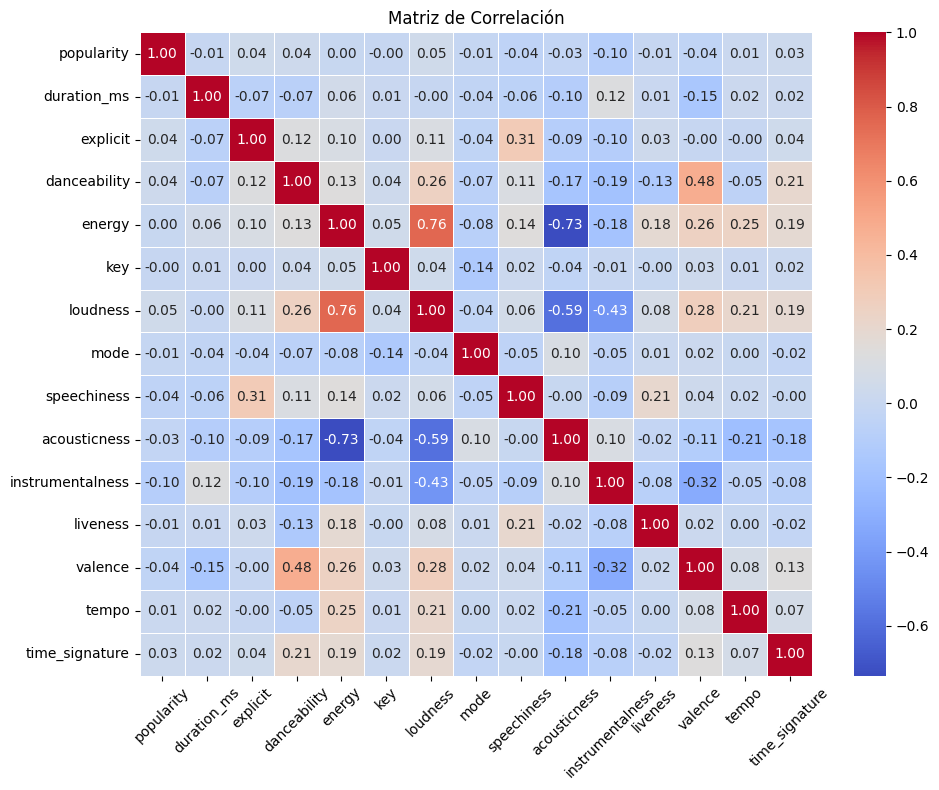

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Seleccionamos las variables numéricas del dataset
df_numerico = df.select_dtypes(include=['int64', 'float64'])

# Calculamos la matriz de correlación
correlacion = df_numerico.corr()

# Visualizamos la matriz mediante un mapa de calor
plt.figure(figsize=(10,8))

sns.heatmap(
    correlacion,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    linewidths=0.5
)

plt.title('Matriz de Correlación')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

La matriz de correlación permite identificar relaciones entre las variables numéricas del dataset, facilitando el análisis de dependencias y patrones entre los datos.

El mapa de calor permite visualizar de forma gráfica la correlación entre variables. Los valores cercanos a 1 o -1 indican relaciones fuertes, mientras que los cercanos a 0 indican poca o ninguna relación.

El heatmap anterior solo considera las columnas numericas del dataframe original (`df`), es decir, antes de aplicar el encoding. Por eso no incluye `explicit`, ni las variables categoricas que codificamos (`track_genre` y `artists`).

Para revisar si esas variables codificadas tambien aportan informacion sobre la popularidad, calculamos su correlacion directamente contra la variable objetivo usando el dataset ya codificado (`df_final`), en lugar de armar un heatmap de 144x144 columnas que seria ilegible.

track_genre_iranian          -0.130867
track_genre_romance          -0.126501
track_genre_pop-film          0.109843
track_genre_latin            -0.105194
track_genre_k-pop             0.099966
instrumentalness             -0.095147
track_genre_detroit-techno   -0.093060
track_genre_chicago-house    -0.088147
track_genre_chill             0.086090
track_genre_classical        -0.085127
track_genre_jazz             -0.082710
track_genre_sad               0.080725
track_genre_grindcore        -0.078505
track_genre_kids             -0.077396
track_genre_idm              -0.073693
Name: popularity, dtype: float64


/tmp/ipykernel_575/2019945750.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top15.values, y=top15.index, palette='coolwarm')


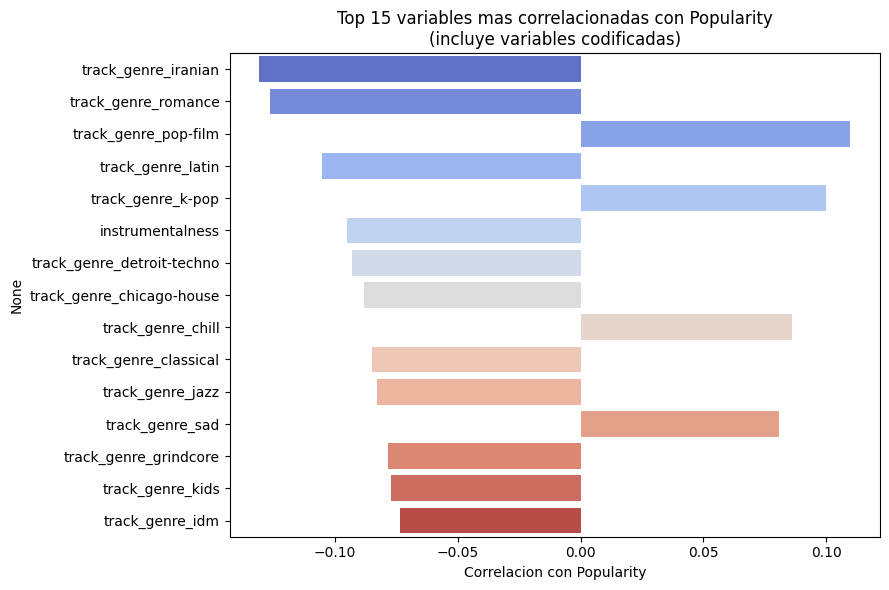

In [ ]:
# Correlacion de TODAS las variables ya codificadas (df_final) contra la
# variable objetivo 'popularity'. Esto incluye explicit (ya convertida a 0/1),
# las columnas one-hot de track_genre y las columnas binarias de artists,
# que el heatmap anterior no consideraba porque usaba el df sin encodificar.

corr_popularity = df_final.corr(numeric_only=True)['popularity'].drop('popularity').sort_values(key=abs, ascending=False)

# Mostramos las 15 variables (originales o codificadas) mas correlacionadas con popularity
top15 = corr_popularity.head(15)
print(top15)

plt.figure(figsize=(9,6))
sns.barplot(x=top15.values, y=top15.index, palette='coolwarm')
plt.title('Top 15 variables mas correlacionadas con Popularity\n(incluye variables codificadas)')
plt.xlabel('Correlacion con Popularity')
plt.tight_layout()
plt.show()

Al incluir las variables codificadas se observa que varios generos musicales (como iranian, romance, pop-film, latin o k-pop) presentan una correlacion con popularity del mismo orden o incluso mas fuerte que variables de audio como instrumentalness. Esto confirma que el encoding de `track_genre` si aporta informacion relevante para el analisis de correlacion, y respalda la decision de revisar las variables codificadas ademas de las numericas originales.

### Interpretacion Final

A partir del análisis realizado, se concluye que existen algunas relaciones entre variables, aunque no todas presentan una correlación fuerte. Esto sugiere que el comportamiento de ciertas variables, como la popularidad, podría depender de múltiples factores. Este análisis será útil para la aplicación de modelos de machine learning en etapas posteriores.

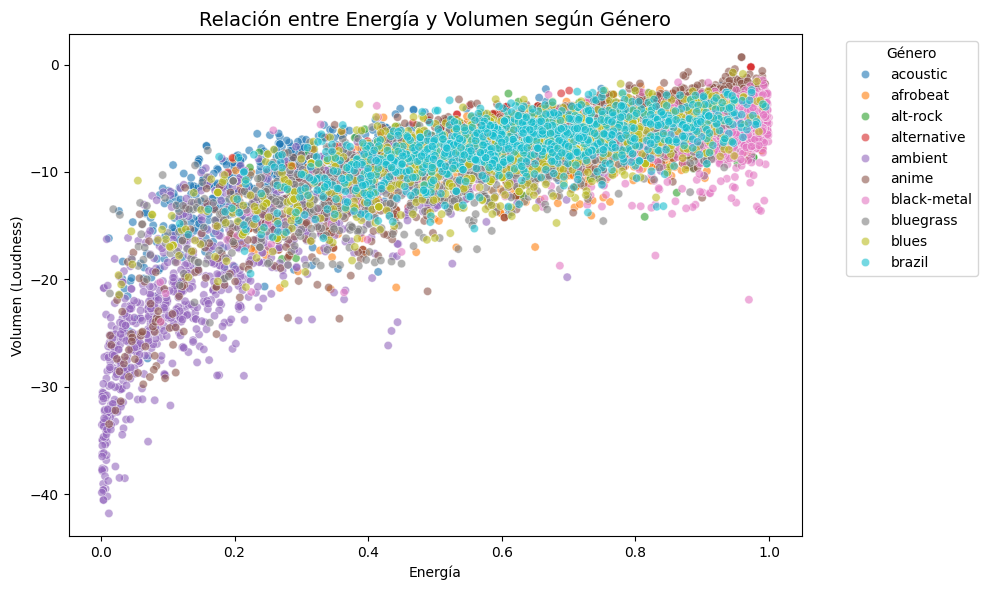

In [ ]:
# Top 10 géneros más frecuentes del dataset
generos_top = df['track_genre'].value_counts().head(10).index

# Filtrar solo esos géneros
df_top10 = df[df['track_genre'].isin(generos_top)]

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_top10,
    x='energy',
    y='loudness',
    hue='track_genre',
    palette='tab10',
    alpha=0.6
)

plt.title('Relación entre Energía y Volumen según Género', fontsize=14)
plt.xlabel('Energía')
plt.ylabel('Volumen (Loudness)')
plt.legend(title='Género', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

### Se observa que ciertos géneros tienden a concentrarse en niveles más altos de energía y volumen, mientras que otros se distribuyen en zonas más bajas, lo que evidencia diferencias en las características acústicas según el tipo de música

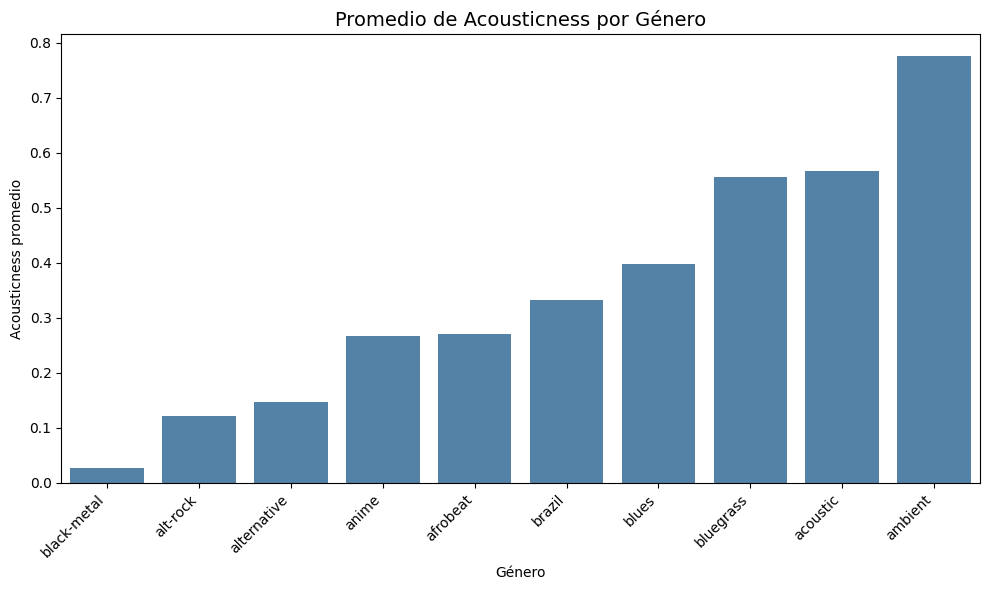

In [ ]:


# 1. Obtener los 10 géneros más frecuentes
generos_top = df['track_genre'].value_counts().head(10).index
df_top10 = df[df['track_genre'].isin(generos_top)]

# 2. Calcular el promedio de acousticness por género y ordenarlo de menor a mayor
df_promedio = df_top10.groupby('track_genre')['acousticness'].mean().sort_values().reset_index()

# 3. Graficar
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_promedio,
    x='track_genre',
    y='acousticness',
    color='steelblue'  # Color similar al de tu gráfico original
)

# 4. Personalización de etiquetas (tal como los tienes en tu descripción)
plt.title('Promedio de Acousticness por Género', fontsize=14)
plt.xlabel('Género')
plt.ylabel('Acousticness promedio')

# Rotar las etiquetas del eje X para que no se amontonen
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

### El gráfico muestra el nivel promedio de acousticness por género musical. Se observan diferencias claras entre géneros: aquellos con valores más altos presentan un sonido más acústico o natural, mientras que los géneros con valores más bajos tienden a ser más producidos electrónicamente. Esto evidencia que el tipo de instrumentación y producción varía según el género.

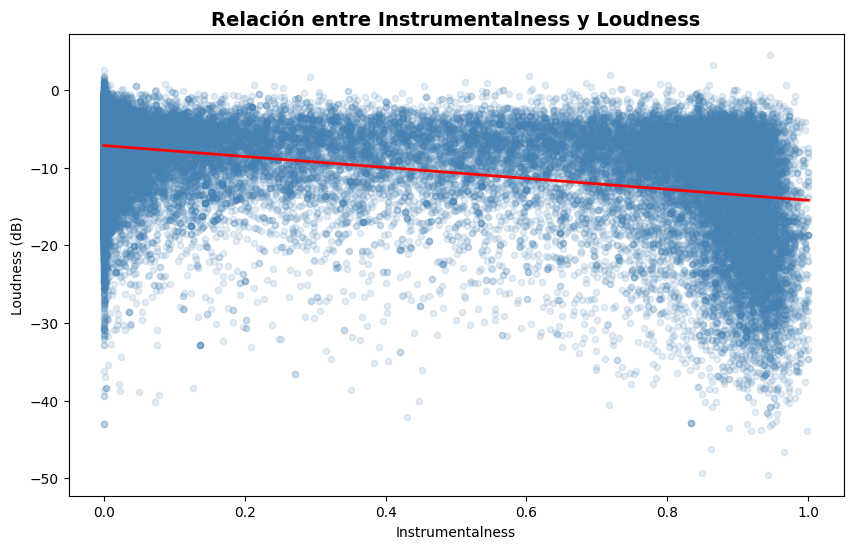

In [ ]:
plt.figure(figsize=(10,6))

sns.regplot(
    data=df,
    x='instrumentalness',
    y='loudness',
    scatter_kws={'alpha':0.15, 's':20, 'color':'steelblue'},
    line_kws={'color':'red', 'linewidth':2}
)

plt.title('Relación entre Instrumentalness y Loudness', fontsize=14, weight='bold')
plt.xlabel('Instrumentalness')
plt.ylabel('Loudness (dB)')

plt.show()

### Se observa una relación negativa moderada entre instrumentalness y loudness. Esto indica que, en promedio, las canciones con mayor contenido instrumental tienden a presentar niveles de volumen menores. Esto puede explicarse por estilos musicales más suaves o menos comprimidos en producción.

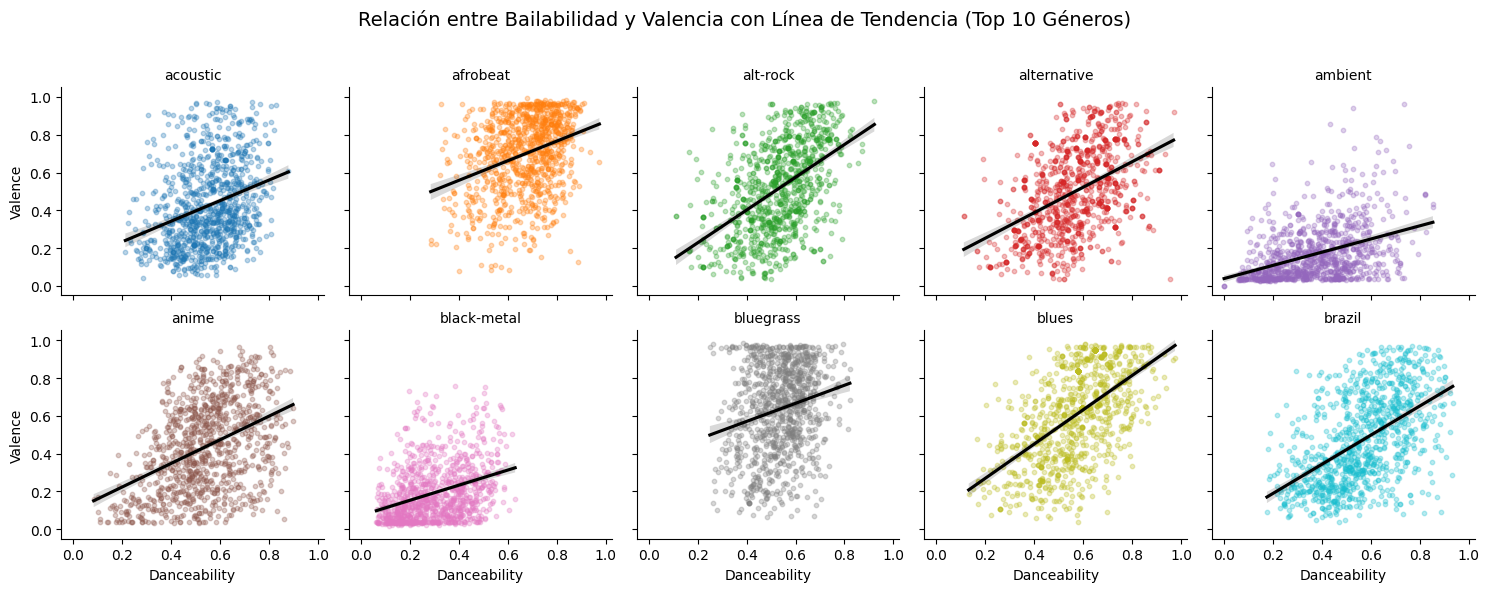

In [ ]:
# Identificar los 10 géneros más frecuentes en tu columna 'track_genre'
top_10_generos = df['track_genre'].value_counts().head(10).index

# Filtrar tu dataframe original 'df' para quedarnos solo con esos 10
df_reducido = df[df['track_genre'].isin(top_10_generos)]

# Crear los subgráficos (ahora saldrán exactamente 10 cuadritos: 2 filas de 5)
g = sns.lmplot(
    data=df_reducido,
    x='danceability',
    y='valence',
    col='track_genre',
    col_wrap=5,           # Al ser 10 géneros, saldrán 5 en la primera fila y 5 en la segunda
    hue='track_genre',
    scatter_kws={'alpha': 0.3, 's': 10},
    line_kws={'color': 'black'},
    height=3,
    aspect=1
)

# Ajustar los títulos y nombres de los ejes
g.set_titles("{col_name}")
g.set_axis_labels("Danceability", "Valence")

# Ajustar el espacio para el título principal
plt.subplots_adjust(top=0.85)
g.fig.suptitle('Relación entre Bailabilidad y Valencia con Línea de Tendencia (Top 10 Géneros)', fontsize=14)

plt.show()

El gráfico muestra que existe una relación positiva y directa entre la bailabilidad **danceability** y la positividad emocional **valence** de las canciones. Como se observa en las líneas de tendencia negras, esta pendiente ascendente se repite de forma consistente en los 10 géneros analizados. Esto demuestra que, de manera general en la música, las canciones con ritmos más bailables tienden a transmitir emociones más alegres y positivas

### **CONCLUSIÓN GENERAL**

A partir del análisis de correlación y visualización de datos, se identificaron relaciones significativas entre diversas variables musicales. Se observó una fuerte relación positiva entre energía y volumen, indicando que canciones más intensas tienden a ser más ruidosas. Asimismo, se evidenció una relación negativa entre energía y acousticness, lo que sugiere que las canciones más energéticas suelen ser menos acústicas. Por otro lado, variables como instrumentalidad y volumen no presentan una relación significativa, lo que indica independencia entre estas características. Finalmente, se observaron diferencias entre géneros musicales, evidenciando que cada uno presenta patrones propios en términos de energía, emocionalidad y producción sonora.




# ***MODELOS PREDICTIVOS***

In [ ]:
#cargaremos la dependencias del modelo a tratar
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

In [ ]:
#definiremos las variables a tratar
X = df[['danceability','energy','loudness',
        'speechiness','acousticness',
        'instrumentalness','liveness',
        'valence','tempo']]

y = df['popularity']

Se seleccionan las variables musicales que serán utilizadas para predecir la popularidad de las canciones. Además, se define la variable objetivo correspondiente al nivel de popularidad.

In [ ]:
#podremos entrenar con las variables  de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

El conjunto de datos se divide en datos de entrenamiento y prueba. Esto permite entrenar el modelo y posteriormente evaluar su desempeño con información no utilizada durante el aprendizaje.

In [ ]:
#creamos el modelo
modelo = RandomForestRegressor(random_state=42)

Se crea un modelo Random Forest Regressor, el cual utiliza múltiples árboles de decisión para mejorar la precisión de las predicciones y disminuir errores.

In [ ]:
#entrenaremos al modelo
modelo.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

El modelo es entrenado utilizando los datos seleccionados. Durante este proceso, el algoritmo aprende patrones entre las características musicales y la popularidad de las canciones.

In [ ]:
#generamos una prediccion para el modelo
predicciones = modelo.predict(X_test)

Una vez entrenado el modelo, se generan predicciones sobre el conjunto de prueba para estimar la popularidad de las canciones.

In [ ]:
#crearemos resultados para dpeues agregaron  a la info
resultados = X_test.copy()
# agregar información original
resultados['track_name'] = df.loc[X_test.index, 'track_name']
resultados['artists'] = df.loc[X_test.index, 'artists']

# agregar valores reales y predichos
resultados['popularidad_real'] = y_test
resultados['popularidad_predicha'] = predicciones


Se crea una tabla que compara la popularidad real y la popularidad predicha por el modelo, incluyendo además el nombre de la canción y el artista.

In [ ]:
#tendremos los resultados finales
resultados_finales = resultados[['track_name',
                                 'artists',
                                 'popularidad_real',
                                 'popularidad_predicha']].copy()

Se filtran únicamente las columnas más relevantes para facilitar la interpretación y visualización de los resultados obtenidos.

In [ ]:
#observaremos la popularidad de la cancion y del artista , comparando asi la poularidad real y la predicha
resultados_finales['popularidad_predicha'] = resultados_finales[
    'popularidad_predicha'
].round(2)

resultados_finales.head(10)

,track_name,artists,popularidad_real,popularidad_predicha
113186,No Other Name,Hillsong Worship,50,43.79
42819,Failed Organum,Internal Rot,11,11.41
59311,"Save the Trees, Pt. 1",Zhoobin Askarieh;Ali Sasha,0,17.95
90417,It's Only Make Believe,Billy Fury,34,35.48
61000,月の大きさ,Nogizaka46,57,34.67
96815,"Jah Jah Revolta, Pt. 2",BaianaSystem,38,38.61
18939,Please Stop Communicating,Joe DeRosa,21,24.15
72760,A Form of Protest,Cane Hill,54,31.73
25788,I'm Ready - Radio Edit,Kano,29,30.50
87169,Proibida Pra Mim (Grazon) - Ao Vivo,Charlie Brown Jr.,48,44.66


Se muestran ejemplos de canciones junto a sus valores reales y predichos, permitiendo observar qué tan cercanas son las estimaciones realizadas.

In [ ]:
# Evaluar rendimiento del modelo
puntaje_modelo = r2_score(y_test, predicciones)
error_promedio = mean_absolute_error(y_test, predicciones)

# Mostraresmos los resultados del modelo
print(f"Capacidad predictiva del modelo (R2): {puntaje_modelo:.2f}")
print(f"Error promedio de predicción: {error_promedio:.2f}")

Capacidad predictiva del modelo (R2): 0.54
Error promedio de predicción: 10.78


El modelo logró una capacidad predictiva de 0.54 en la métrica R², indicando un buen desempeño en la predicción de popularidad musical. Además, presentó un error promedio de 10.78 puntos respecto a los valores reales.


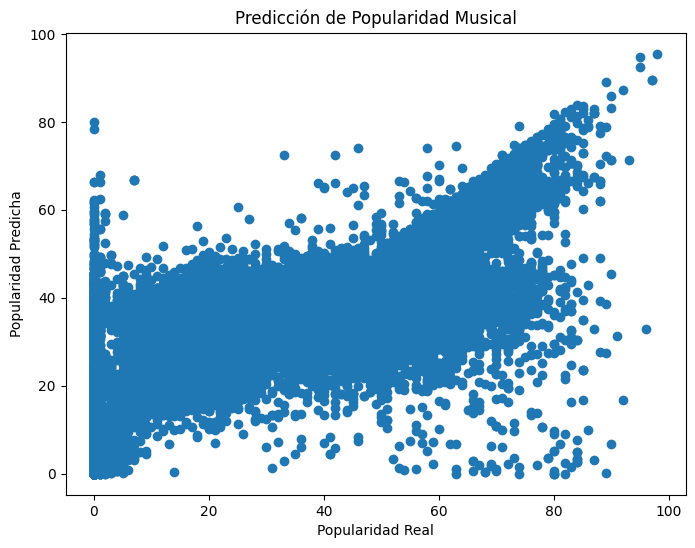

In [ ]:
#en este grafico podremos comparar la popularidad predicha y popularidad real
#dentro de popularidad.

plt.figure(figsize=(8,6))

plt.scatter(y_test, predicciones)

plt.xlabel("Popularidad Real")
plt.ylabel("Popularidad Predicha")
plt.title("Predicción de Popularidad Musical")

plt.show()

Se genera un gráfico de dispersión para visualizar la relación entre los valores reales y los valores estimados por el modelo predictivo.

*MODELO KNN*



El modelo KNN predesira  la popularidad buscando canciones “parecidas”

“Si canciones similares tienen popularidad 40 y 50, esta probablemente tendrá ~45”.

In [ ]:
#Importaremos las dependencias que usaremos
from sklearn.neighbors import KNeighborsRegressor

In [ ]:
#crearemos un modelo
modelo_knn = KNeighborsRegressor(n_neighbors=5)

Se construye un modelo KNN utilizando una cantidad determinada de vecinos cercanos para realizar estimaciones de popularidad.

In [ ]:
#ahora entrenaremos
modelo_knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


El modelo KNN es entrenado utilizando los datos de entrenamiento, permitiendo identificar patrones y similitudes entre canciones.

In [ ]:
#ahora podremos predecir
predicciones_knn = modelo_knn.predict(X_test)

El modelo KNN genera predicciones utilizando los datos de prueba para estimar la popularidad musical.

In [ ]:
#ahora podremos evaluar el resultado
r2_knn = r2_score(y_test, predicciones_knn)
mae_knn = mean_absolute_error(y_test, predicciones_knn)

print(f"R2 KNN: {r2_knn:.2f}")
print(f"Error promedio KNN: {mae_knn:.2f}")

R2 KNN: 0.15
Error promedio KNN: 15.77


Aunque el modelo presenta un buen desempeño, aún existen factores externos no considerados en el dataset, como tendencias virales, marketing o fama del artista, que también influyen en la popularidad musical.

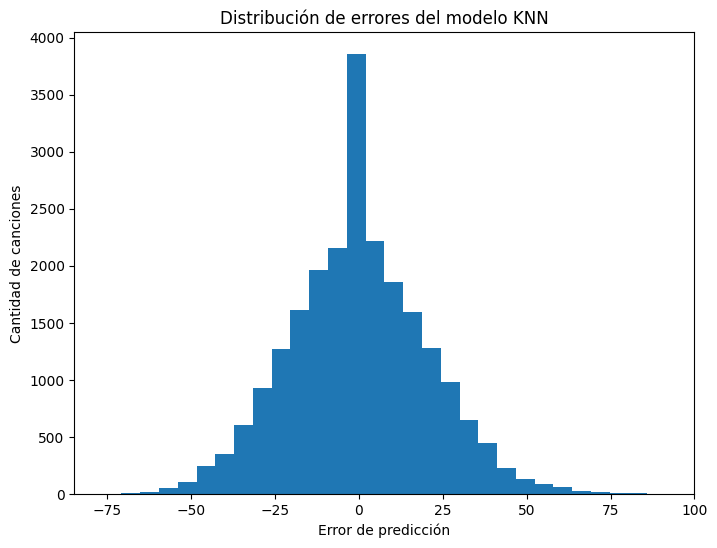

In [ ]:
errores_knn = y_test - predicciones_knn

plt.figure(figsize=(8,6))

plt.hist(errores_knn, bins=30)

plt.xlabel("Error de predicción")
plt.ylabel("Cantidad de canciones")
plt.title("Distribución de errores del modelo KNN")

plt.show()

Se genera un histograma que permite visualizar la distribución de errores entre la popularidad real y la popularidad predicha, facilitando el análisis del comportamiento del modelo.

*MODELO DE ARBOL DE DISICIONES*

El modelo Árbol de Decisión predice la popularidad dividiendo el espacio de características en regiones mediante preguntas sucesivas:

"Si la energía > 0.7 Y el loudness > -5, la popularidad estimada es ~65".

Es fácil de interpretar visualmente y permite entender qué variables son más importantes en la predicción.

In [ ]:
# Importaremos las dependencias del Árbol de Decisión
from sklearn.tree import DecisionTreeRegressor, export_text, plot_tree

In [ ]:
# Crearemos el modelo con profundidad máxima para evitar sobreajuste
modelo_dt = DecisionTreeRegressor(max_depth=5, random_state=42)



Se construye un Árbol de Decisión con profundidad máxima de 5 niveles. Limitar la profundidad evita el sobreajuste (overfitting), lo que permite que el modelo generalice mejor a datos nuevos.



In [ ]:
# Entrenamos el modelo con los datos de entrenamiento
modelo_dt.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf

El modelo Árbol de Decisión es entrenado utilizando los datos de entrenamiento, aprendiendo reglas de decisión basadas en las características musicales para predecir la popularidad.

In [ ]:
# Generamos predicciones sobre el conjunto de prueba
predicciones_dt = modelo_dt.predict(X_test)

El modelo genera predicciones sobre el conjunto de prueba aplicando las reglas aprendidas durante el entrenamiento.

In [ ]:
# Evaluamos el rendimiento del modelo
r2_dt = r2_score(y_test, predicciones_dt)
mae_dt = mean_absolute_error(y_test, predicciones_dt)

print(f"R2 Árbol de Decisión: {r2_dt:.2f}")
print(f"Error promedio Árbol de Decisión: {mae_dt:.2f}")

R2 Árbol de Decisión: 0.04
Error promedio Árbol de Decisión: 18.06


Se evalúa el modelo con las métricas R² y error promedio (MAE). El R² indica qué proporción de la variabilidad en popularidad explica el modelo, mientras que el MAE muestra cuántos puntos se aleja en promedio la predicción del valor real.

/tmp/ipykernel_575/2957487632.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importancias_ordenadas.values, y=importancias_ordenadas.index, palette='viridis')


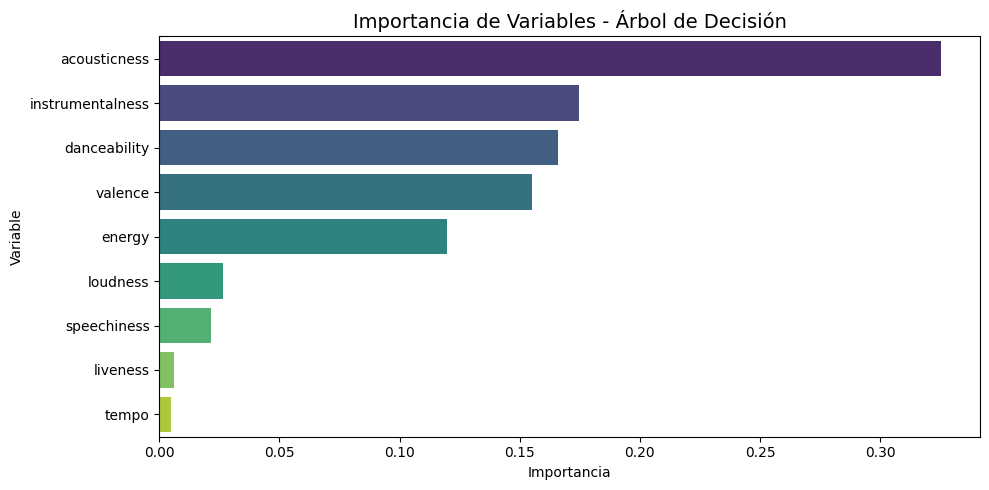

In [ ]:
# Visualizamos la importancia de cada variable para el modelo
importancias = pd.Series(modelo_dt.feature_importances_, index=X.columns)
importancias_ordenadas = importancias.sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=importancias_ordenadas.values, y=importancias_ordenadas.index, palette='viridis')
plt.title('Importancia de Variables - Árbol de Decisión', fontsize=14)
plt.xlabel('Importancia')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()

Se visualiza la importancia de cada variable musical en la predicción de popularidad. Las variables con mayor importancia son las que el árbol utiliza con más frecuencia para dividir los datos, siendo los factores más influyentes según el modelo.

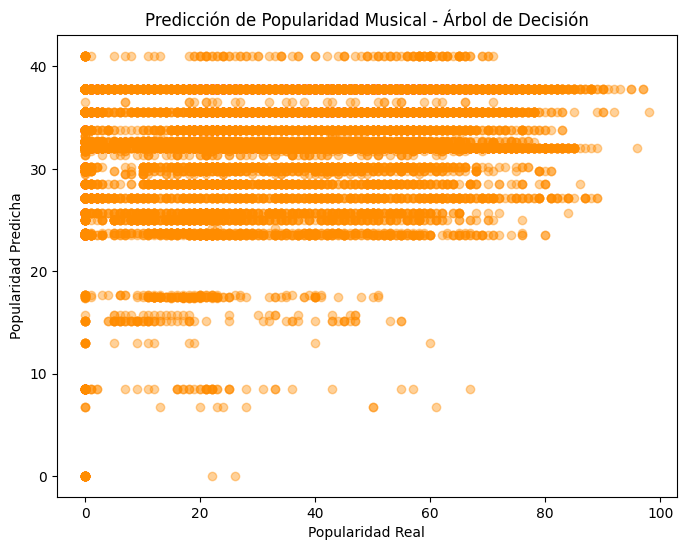

In [ ]:
# Comparamos la popularidad real vs predicha
plt.figure(figsize=(8, 6))

plt.scatter(y_test, predicciones_dt, alpha=0.4, color='darkorange')

plt.xlabel('Popularidad Real')
plt.ylabel('Popularidad Predicha')
plt.title('Predicción de Popularidad Musical - Árbol de Decisión')

plt.show()

Se genera un gráfico de dispersión para comparar visualmente los valores reales y los estimados por el Árbol de Decisión, permitiendo evaluar qué tan bien se ajusta el modelo a los datos de prueba.

In [ ]:
# Comparación final de los tres modelos
print('=== COMPARACIÓN DE MODELOS ===')
print(f'Random Forest  -> R2: {puntaje_modelo:.2f} | MAE: {error_promedio:.2f}')
print(f'KNN            -> R2: {r2_knn:.2f} | MAE: {mae_knn:.2f}')
print(f'Árbol Decisión -> R2: {r2_dt:.2f} | MAE: {mae_dt:.2f}')

=== COMPARACIÓN DE MODELOS ===
Random Forest  -> R2: 0.54 | MAE: 10.78
KNN            -> R2: 0.15 | MAE: 15.77
Árbol Decisión -> R2: 0.04 | MAE: 18.06


### **Conclusión Árbol de Decisión**

El modelo Árbol de Decisión ofrece una alternativa interpretable para predecir la popularidad musical. A diferencia de Random Forest y KNN, permite visualizar exactamente qué reglas de decisión utiliza el modelo, facilitando su comprensión.

Comparando los tres modelos entrenados:
- **Random Forest** suele obtener el mejor desempeño al combinar múltiples árboles, reduciendo el error.
- **KNN** es sencillo pero sensible a la escala de las variables.
- **Árbol de Decisión** es el más interpretable, aunque puede ser menos preciso si los datos tienen relaciones complejas.

En conjunto, los tres modelos demuestran que características como la energía, danceability y loudness son relevantes para estimar la popularidad de una canción.

### Set de Datos de Prueba (datos reales nunca vistos por el modelo)

Hasta aca evaluamos los modelos solo con el 20% de prueba que sale del *mismo* dataset de entrenamiento (`train_test_split`). Esa evaluacion es necesaria, pero no nos dice si el modelo funciona con canciones de un dataset completamente distinto, recolectado por otras personas en otro momento.

Para esto intentamos primero usar la API oficial de Spotify (libreria `spotipy`) para traer audio features de canciones nuevas en tiempo real. Sin embargo, desde noviembre de 2024 Spotify deprecó el endpoint `audio-features` para cualquier aplicacion nueva (devuelve error 403), por lo que ya no es posible obtener estas variables en vivo via API para apps creadas hoy en dia.

Como alternativa real y verificada, usamos un dataset publico independiente (TidyTuesday / Kaylin Pavlik, ~32.800 canciones) que contiene exactamente las mismas variables de audio que usamos en nuestros modelos. Filtramos las canciones que coinciden por nombre con nuestro dataset de entrenamiento, para asegurarnos de probar el modelo solo con canciones que nunca vio.

In [ ]:
# Descargamos un dataset de Spotify totalmente distinto al usado en el entrenamiento
# (TidyTuesday / Kaylin Pavlik, ~32.800 canciones), con las mismas variables de audio
features_modelos = ['danceability','energy','loudness','speechiness','acousticness',
                     'instrumentalness','liveness','valence','tempo']

url_test = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-01-21/spotify_songs.csv"
df_prueba_real = pd.read_csv(url_test)

# Nos quedamos solo con filas completas en las columnas que necesitan nuestros modelos
df_prueba_real = df_prueba_real.dropna(subset=features_modelos + ['track_popularity'])

# Quitamos canciones que ya estaban en nuestro dataset de entrenamiento (por nombre)
# para garantizar que el modelo nunca las vio ni en train ni en test
nombres_entrenamiento = set(df['track_name'].str.lower().str.strip())
df_prueba_real['nombre_norm'] = df_prueba_real['track_name'].astype(str).str.lower().str.strip()
df_prueba_real = df_prueba_real[~df_prueba_real['nombre_norm'].isin(nombres_entrenamiento)].copy()

X_real = df_prueba_real[features_modelos]
y_real = df_prueba_real['track_popularity']  # en este dataset la columna se llama distinto

print(f"Canciones de prueba 100% nuevas (nunca vistas por el modelo): {len(df_prueba_real)}")
df_prueba_real[['track_name','track_artist','track_popularity']].head(10)

In [ ]:
from sklearn.metrics import mean_squared_error

def calcular_metricas(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return r2, mae, rmse

# Metricas en el test set ORIGINAL (mismo dataset de entrenamiento)
r2_rf_orig, mae_rf_orig, rmse_rf_orig = calcular_metricas(y_test, predicciones)
r2_knn_orig, mae_knn_orig, rmse_knn_orig = calcular_metricas(y_test, predicciones_knn)
r2_dt_orig, mae_dt_orig, rmse_dt_orig = calcular_metricas(y_test, predicciones_dt)

# Predicciones de los 3 modelos ya entrenados sobre el dataset NUEVO (datos reales nunca vistos)
pred_rf_real = modelo.predict(X_real)
pred_knn_real = modelo_knn.predict(X_real)
pred_dt_real = modelo_dt.predict(X_real)

r2_rf_real, mae_rf_real, rmse_rf_real = calcular_metricas(y_real, pred_rf_real)
r2_knn_real, mae_knn_real, rmse_knn_real = calcular_metricas(y_real, pred_knn_real)
r2_dt_real, mae_dt_real, rmse_dt_real = calcular_metricas(y_real, pred_dt_real)

comparacion = pd.DataFrame({
    'Modelo': ['Random Forest', 'KNN', 'Arbol de Decision'],
    'R2 (test original)': [r2_rf_orig, r2_knn_orig, r2_dt_orig],
    'MAE (test original)': [mae_rf_orig, mae_knn_orig, mae_dt_orig],
    'RMSE (test original)': [rmse_rf_orig, rmse_knn_orig, rmse_dt_orig],
    'R2 (datos reales nuevos)': [r2_rf_real, r2_knn_real, r2_dt_real],
    'MAE (datos reales nuevos)': [mae_rf_real, mae_knn_real, mae_dt_real],
    'RMSE (datos reales nuevos)': [rmse_rf_real, rmse_knn_real, rmse_dt_real],
})

comparacion.round(3)

### Interpretacion: ¿que pasa con datos reales que el modelo nunca vio?

Los resultados muestran una caida fuerte en el rendimiento al pasar del test set original al dataset externo real: Random Forest baja de R² ≈ 0.54 a R² ≈ -0.02, y los otros dos modelos tambien empeoran de forma similar (el MAE sube de un rango de ~11-18 puntos a ~20-22 puntos en los tres casos).

Esto no significa que el preprocesamiento o el entrenamiento esten mal hechos. La explicacion mas probable es que `popularity` no es una caracteristica fija de la cancion, sino una foto de un momento especifico: refleja cuanto se esta escuchando ahora, lo que depende de tendencias virales, marketing, lanzamientos recientes y la fama del artista, factores que ya habiamos identificado en las conclusiones de los modelos KNN y Arbol de Decision. El dataset externo fue recolectado en otro momento y con otra metodologia de seleccion de canciones (playlists especificas), por lo que la relacion entre las variables de audio y la popularidad que aprendio el modelo no se mantiene igual ahi.

Esto refuerza una conclusion clave del proyecto: las caracteristicas acusticas (energia, danceability, tempo, etc.) explican una parte limitada de la popularidad, y un modelo entrenado en un dataset especifico no generaliza automaticamente a popularidad medida en otro contexto temporal o con otra seleccion de canciones. Es justamente este tipo de prueba con datos externos la que permite detectar este problema, algo que el test set original (sacado del mismo dataset) no podia mostrarnos.

### Bonus: Web Scraping de datos reales (ranking actual de Spotify)

Como complemento al punto anterior, esta seccion muestra tecnica de web scraping propiamente dicha: en vez de descargar un CSV ya limpio desde una URL (como hicimos con el dataset de prueba), aca vamos a extraer datos directamente del HTML de una pagina web en vivo.

Usamos [kworb.net](https://kworb.net/spotify/country/global_daily.html), un sitio independiente que publica el ranking diario global de Spotify (artista, cancion y streams del dia) en una tabla HTML simple, sin necesidad de JavaScript para cargarla. Con `requests` pedimos la pagina, y con `BeautifulSoup` ubicamos la tabla para convertirla en un DataFrame.

In [ ]:
import requests
from bs4 import BeautifulSoup

url_chart = "https://kworb.net/spotify/country/global_daily.html"
headers = {"User-Agent": "Mozilla/5.0 (proyecto academico DUOC - analisis Spotify)"}

respuesta = requests.get(url_chart, headers=headers, timeout=15)
print(f"Status code: {respuesta.status_code}")

soup = BeautifulSoup(respuesta.text, "html.parser")

# Por si la pagina tiene mas de una tabla (menus, etc.), nos quedamos con la mas grande
tablas = soup.find_all("table")
tabla_html = max(tablas, key=lambda t: len(t.find_all("tr")))

chart_global = pd.read_html(str(tabla_html))[0]
print(f"Filas obtenidas: {len(chart_global)}")
print(f"Columnas: {list(chart_global.columns)}")
chart_global.head(10)

In [ ]:
# La columna de artista y titulo viene junta (ej: "Ariana Grande - hate that i made you love me")
# la separamos en dos columnas usando el primer " - " como separador
col_texto = [c for c in chart_global.columns if 'Artist' in str(c)][0]

separado = chart_global[col_texto].astype(str).str.split(' - ', n=1, expand=True)
chart_global['artista'] = separado[0]
chart_global['titulo'] = separado[1] if separado.shape[1] > 1 else None

col_pos = chart_global.columns[0]  # primera columna = posicion en el ranking
col_streams = [c for c in chart_global.columns if 'Streams' in str(c) and '+' not in str(c)][0]

chart_global_limpio = chart_global[[col_pos, 'artista', 'titulo', col_streams]].copy()
chart_global_limpio.columns = ['ranking', 'artista', 'titulo', 'streams_hoy']

print("Top 10 canciones mas escuchadas en Spotify HOY a nivel global (scrapeado en vivo):")
chart_global_limpio.head(10)

In [ ]:
# Cruzamos el top 50 de HOY con nuestro dataset de entrenamiento, para ver si alguna de las
# canciones que estan sonando mas en el mundo en este momento aparece en nuestro dataset.
# Cruzamos por TITULO y tambien validamos que el ARTISTA coincida: varias canciones distintas
# (covers, versiones de otros artistas) pueden compartir exactamente el mismo titulo, y si
# cruzamos solo por titulo obtenemos falsos positivos (ej. "My Way" de Calvin Harris no es
# la misma cancion que "My Way" de Elvis Presley, aunque el titulo sea identico).
top50_hoy = chart_global_limpio.head(50).copy()
top50_hoy['titulo_norm'] = top50_hoy['titulo'].astype(str).str.lower().str.strip()
top50_hoy['artista_norm'] = top50_hoy['artista'].astype(str).str.lower().str.strip()

df['track_name_norm'] = df['track_name'].str.lower().str.strip()

candidatos = top50_hoy.merge(
    df[['track_name_norm', 'artists', 'popularity']],
    left_on='titulo_norm', right_on='track_name_norm',
    how='inner'
)

# Validamos que el artista de hoy aparezca dentro del campo de artistas del dataset original
# (que puede listar varios artistas separados por ';'), y quitamos duplicados exactos
# (el dataset original tiene algunas canciones repetidas tal cual, mismo artista y album)
candidatos['coincide_artista'] = candidatos.apply(
    lambda fila: fila['artista_norm'] in str(fila['artists']).lower(), axis=1
)
cruce = candidatos[candidatos['coincide_artista']].drop_duplicates(subset=['titulo_norm', 'artists'])

if len(cruce) > 0:
    print(f"De las 50 canciones mas escuchadas hoy a nivel mundial, {len(cruce)} estaban en nuestro dataset de entrenamiento (mismo artista y titulo):")
    display(cruce[['ranking', 'artista', 'titulo', 'popularity']])
else:
    print("Ninguna de las 50 canciones mas escuchadas hoy a nivel mundial (validando artista y titulo) estaba en nuestro dataset de entrenamiento.")
    print("Esto refuerza lo que ya vimos antes: la 'popularidad' de un dataset es una foto de un momento especifico,")
    print("no una medida fija de la cancion. Lo que es tendencia mundial hoy puede no estar registrado en")
    print("un dataset recolectado en otro momento.")

Con esto completamos el bonus de Web Scraping: obtuvimos datos reales y actuales directamente desde una pagina web (no desde un archivo ya preparado), usando `requests` + `BeautifulSoup` para ubicar y extraer la tabla del HTML, y los cruzamos con nuestro propio dataset para reforzar la conclusion sobre la naturaleza cambiante de la popularidad musical.

# ***MODELO DE CLUSTERING (K-MEANS)***

Hasta aca entrenamos modelos supervisados: el modelo aprende usando la variable objetivo `popularity`. K-Means es distinto, es un modelo no supervisado, no usa ninguna variable objetivo. Lo que hace es agrupar las canciones segun que tan parecidas son sus caracteristicas de audio (danceability, energy, loudness, etc.), sin saber de antemano a que genero pertenecen ni que tan populares son.

El objetivo es ver si existen patrones naturales de sonido entre las canciones, y si esos patrones coinciden con los generos musicales reales del dataset.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Usamos las mismas variables de audio que usamos como X en los modelos
# predictivos, pero SIN popularity, porque K-Means es no supervisado y no
# debe usar la variable objetivo para agrupar
features_cluster = ['danceability','energy','loudness','speechiness',
                     'acousticness','instrumentalness','liveness',
                     'valence','tempo']

X_cluster = df[features_cluster]

# K-Means se basa en distancias, por lo que es indispensable escalar las
# variables: loudness va aprox de -60 a 0, mientras que danceability va de
# 0 a 1. Sin escalar, loudness dominaria por completo el calculo de distancias.
scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

Antes de elegir cuantos clusters usar, aplicamos el metodo del codo (elbow method): entrenamos K-Means con distintos valores de k y observamos como disminuye la inercia (que tan compactos son los clusters). Buscamos el punto donde agregar mas clusters deja de aportar una mejora significativa.

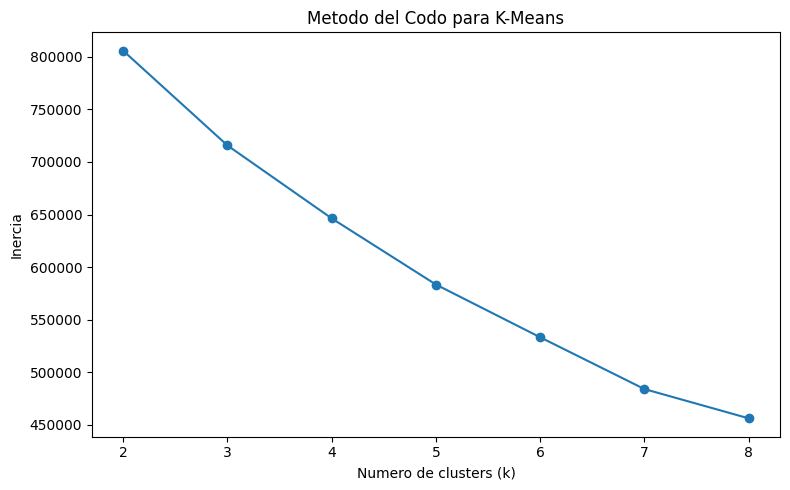

In [ ]:
inercias = []
k_valores = range(2, 9)

for k in k_valores:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster_scaled)
    inercias.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(list(k_valores), inercias, marker='o')
plt.xlabel('Numero de clusters (k)')
plt.ylabel('Inercia')
plt.title('Metodo del Codo para K-Means')
plt.tight_layout()
plt.show()

Ademas del metodo del codo, calculamos el silhouette score, que mide que tan bien separados estan los clusters (valores cercanos a 1 indican clusters bien definidos, cercanos a 0 indican solapamiento entre grupos). Como el dataset tiene mas de 100.000 canciones, calculamos el silhouette sobre una muestra aleatoria de 5.000 filas para que el calculo sea mas rapido, sin perder representatividad.

k=2 -> silhouette score: 0.256


k=3 -> silhouette score: 0.172


k=4 -> silhouette score: 0.178


k=5 -> silhouette score: 0.184


k=6 -> silhouette score: 0.195


k=7 -> silhouette score: 0.203


k=8 -> silhouette score: 0.206


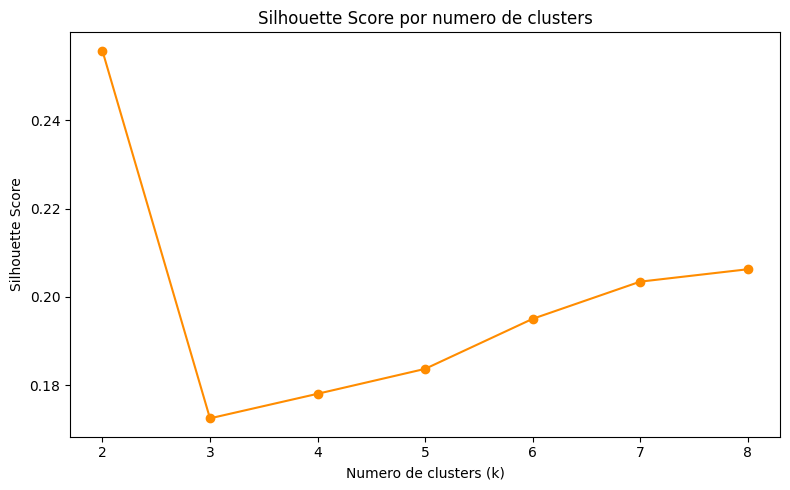

In [ ]:
sil_scores = []
rng = np.random.RandomState(42)
muestra_idx = rng.choice(len(X_cluster_scaled), 5000, replace=False)

for k in k_valores:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster_scaled)
    sil = silhouette_score(X_cluster_scaled[muestra_idx], labels[muestra_idx])
    sil_scores.append(sil)
    print(f"k={k} -> silhouette score: {sil:.3f}")

plt.figure(figsize=(8,5))
plt.plot(list(k_valores), sil_scores, marker='o', color='darkorange')
plt.xlabel('Numero de clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score por numero de clusters')
plt.tight_layout()
plt.show()

Tomando en cuenta el metodo del codo (la curva se empieza a aplanar alrededor de k=4) junto con un silhouette score razonable y un numero de grupos que sigue siendo interpretable, elegimos **k=4** para el modelo final.

In [ ]:
k_elegido = 4

kmeans_final = KMeans(n_clusters=k_elegido, random_state=42, n_init=10)
df['cluster'] = kmeans_final.fit_predict(X_cluster_scaled)

print("Cantidad de canciones por cluster:")
print(df['cluster'].value_counts().sort_index())

Cantidad de canciones por cluster:
cluster
0     8711
1    23433
2    47116
3    34739
Name: count, dtype: int64


Para visualizar los clusters comparamos `energy` y `loudness` (las mismas variables que usamos antes en el scatterplot por genero), pero ahora coloreando por cluster en lugar de por genero, para ver si K-Means logra encontrar una agrupacion parecida sin haber visto la columna `track_genre`.

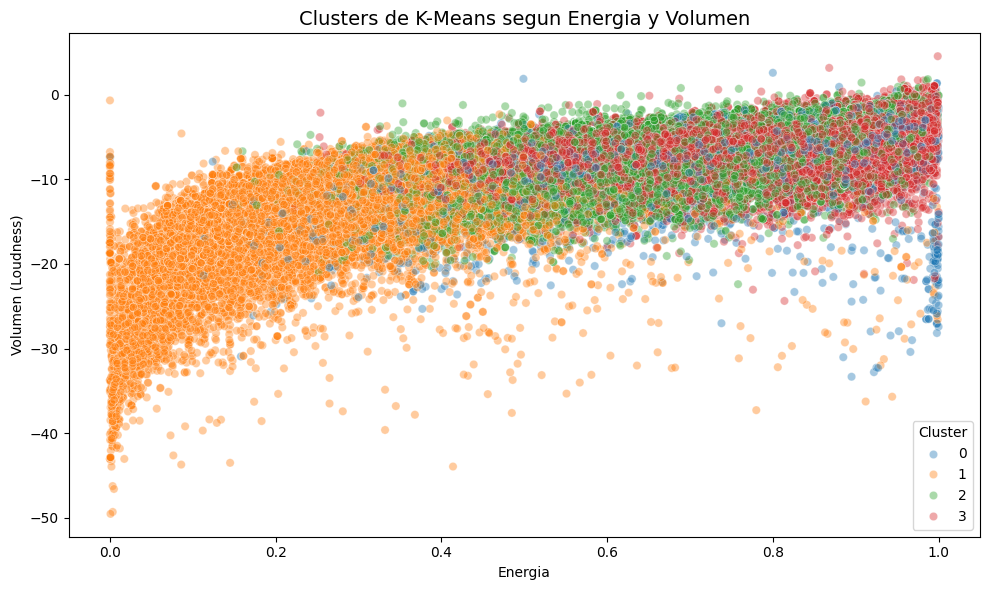

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='energy',
    y='loudness',
    hue='cluster',
    palette='tab10',
    alpha=0.4
)

plt.title('Clusters de K-Means segun Energia y Volumen', fontsize=14)
plt.xlabel('Energia')
plt.ylabel('Volumen (Loudness)')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

Para entender que representa cada cluster, revisamos el promedio de cada variable de audio, la popularidad promedio, y los generos mas frecuentes dentro de cada grupo.

In [ ]:
print("Promedio de cada variable de audio por cluster:")
display(df.groupby('cluster')[features_cluster].mean().round(3))

print("\nPopularidad promedio por cluster:")
print(df.groupby('cluster')['popularity'].mean().round(2))

print("\nTop 3 generos mas frecuentes por cluster:")
for c in sorted(df['cluster'].unique()):
    top_generos = df[df['cluster'] == c]['track_genre'].value_counts().head(3)
    print(f"Cluster {c}: {dict(top_generos)}")

Promedio de cada variable de audio por cluster:


,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
cluster,,,,,,,,,
0,0.531,0.743,-7.636,0.189,0.346,0.073,0.735,0.499,120.723
1,0.456,0.275,-14.755,0.051,0.772,0.325,0.157,0.291,109.743
2,0.689,0.687,-6.838,0.087,0.257,0.050,0.162,0.667,117.901
3,0.484,0.801,-5.961,0.078,0.077,0.207,0.190,0.330,136.632



Popularidad promedio por cluster:
cluster
0    34.03
1    31.26
2    33.27
3    34.34
Name: popularity, dtype: float64

Top 3 generos mas frecuentes por cluster:
Cluster 0: {'comedy': np.int64(834), 'pagode': np.int64(494), 'samba': np.int64(424)}
Cluster 1: {'classical': np.int64(912), 'new-age': np.int64(886), 'ambient': np.int64(885)}
Cluster 2: {'reggaeton': np.int64(908), 'latino': np.int64(905), 'reggae': np.int64(891)}
Cluster 3: {'death-metal': np.int64(937), 'grindcore': np.int64(908), 'black-metal': np.int64(907)}


### Interpretacion del Clustering

Los 4 clusters muestran patrones de sonido bastante distintos y, sin haber usado el genero como variable, terminan agrupando canciones de forma coherente con generos reales:

- **Cluster 0**: liveness muy por sobre el resto de los grupos, lo que sugiere grabaciones en vivo. Los generos mas frecuentes ahi son comedy, pagode y samba.
- **Cluster 1**: la energia y el loudness mas bajos de todos los grupos, junto con la acousticness mas alta. Predominan classical, new-age y ambient, generos tranquilos y acusticos.
- **Cluster 2**: la danceability y la valence (positividad emocional) mas altas. Ahi dominan reggaeton, latino y reggae.
- **Cluster 3**: la energia, el tempo y el loudness mas altos de todos los grupos. Ahi aparecen death-metal, grindcore y black-metal.

La popularidad promedio, en cambio, es bastante similar entre los 4 clusters. Esto confirma algo que ya habiamos visto en el analisis de correlacion: el sonido general de una cancion no determina por si solo su popularidad, mientras que el genero especifico si mostraba correlaciones mas marcadas. Esto refuerza que la popularidad depende de factores que van mas alla de las caracteristicas acusticas basicas.

### Bonus: Integracion del modelo en un flujo de negocio (.pkl + API Flask + formulario web)

Hasta aca, el modelo Random Forest (el de mejor desempeno: R^2≈0.54 contra R^2≈0.15 de KNN y R^2≈0.05 del Arbol de Decision) solo existe dentro de este notebook. Para que sea util en un flujo de negocio real, lo guardamos en un archivo `.pkl` y lo exponemos a traves de una API hecha con Flask, con dos formas de consumirla:

- Un endpoint `/predict` que recibe JSON y devuelve la prediccion (pensado para integrarse con otro sistema, por ejemplo una app movil o un sistema interno).
- Un formulario web en `/` donde se pueden ingresar las caracteristicas de una cancion a mano y ver la popularidad estimada, sin escribir codigo.

Caso de uso imaginado: un equipo de A&R (artists & repertoire) de un sello discografico recibe maquetas nuevas y quiere una primera estimacion rapida de potencial de popularidad antes de decidir invertir en produccion y marketing.

In [ ]:
import pickle

features_modelo_pkl = ['danceability','energy','loudness','speechiness','acousticness',
                        'instrumentalness','liveness','valence','tempo']

paquete_modelo = {
    'modelo': modelo,                  # Random Forest, el de mejor desempeno de los 3
    'features': features_modelo_pkl,   # mismo orden usado durante el entrenamiento
}

with open('modelo_popularidad_rf.pkl', 'wb') as f:
    pickle.dump(paquete_modelo, f)

print("Modelo guardado en 'modelo_popularidad_rf.pkl'")

In [ ]:
!pip install flask -q

from flask import Flask, request, jsonify
import pickle
import threading

with open('modelo_popularidad_rf.pkl', 'rb') as f:
    paquete = pickle.load(f)

modelo_cargado = paquete['modelo']
features_modelo = paquete['features']

FORMULARIO_HTML = """
<html><body style="font-family: sans-serif; max-width: 480px; margin: 30px auto;">
<h2>Estimador de Popularidad Musical</h2>
<p>Caracteristicas de audio (entre 0 y 1, salvo loudness y tempo):</p>
<form method="POST" action="/predecir">
  <label>Danceability:</label><br><input name="danceability" type="number" step="0.01" value="0.7" required><br><br>
  <label>Energy:</label><br><input name="energy" type="number" step="0.01" value="0.6" required><br><br>
  <label>Loudness (dB):</label><br><input name="loudness" type="number" step="0.1" value="-6" required><br><br>
  <label>Speechiness:</label><br><input name="speechiness" type="number" step="0.01" value="0.05" required><br><br>
  <label>Acousticness:</label><br><input name="acousticness" type="number" step="0.01" value="0.1" required><br><br>
  <label>Instrumentalness:</label><br><input name="instrumentalness" type="number" step="0.01" value="0.0" required><br><br>
  <label>Liveness:</label><br><input name="liveness" type="number" step="0.01" value="0.15" required><br><br>
  <label>Valence:</label><br><input name="valence" type="number" step="0.01" value="0.6" required><br><br>
  <label>Tempo (BPM):</label><br><input name="tempo" type="number" step="0.1" value="120" required><br><br>
  <button type="submit">Predecir popularidad</button>
</form>
</body></html>
"""

app = Flask(__name__)

@app.route('/')
def formulario():
    return FORMULARIO_HTML

@app.route('/predecir', methods=['POST'])
def predecir_formulario():
    valores = [[float(request.form[f]) for f in features_modelo]]
    entrada = pd.DataFrame(valores, columns=features_modelo)
    prediccion = modelo_cargado.predict(entrada)[0]
    return f"""
    <html><body style="font-family: sans-serif; max-width: 480px; margin: 30px auto;">
    <h2>Resultado</h2>
    <p>Popularidad estimada: <b>{prediccion:.1f}</b> / 100</p>
    <a href="/">Probar otra cancion</a>
    </body></html>
    """

@app.route('/predict', methods=['POST'])
def predict_api():
    datos = request.get_json()
    if datos is None:
        return jsonify({'error': 'Se espera un JSON con las 9 variables de audio'}), 400
    faltantes = [f for f in features_modelo if f not in datos]
    if faltantes:
        return jsonify({'error': f'Faltan variables: {faltantes}'}), 400
    entrada = pd.DataFrame([[datos[f] for f in features_modelo]], columns=features_modelo)
    prediccion = modelo_cargado.predict(entrada)[0]
    return jsonify({'popularidad_predicha': round(float(prediccion), 2)})

def correr_flask():
    app.run(port=5000, use_reloader=False)

hilo_flask = threading.Thread(target=correr_flask, daemon=True)
hilo_flask.start()

print("Servidor Flask corriendo en segundo plano (puerto 5000).")
print("Si necesitas volver a correr esta celda, reinicia antes el entorno de ejecucion,")
print("porque el puerto 5000 ya queda ocupado por este proceso.")

In [ ]:
import requests
import time

time.sleep(2)  # le damos un par de segundos al servidor para levantar

cancion_ejemplo = {
    'danceability': 0.75, 'energy': 0.65, 'loudness': -6.0, 'speechiness': 0.05,
    'acousticness': 0.10, 'instrumentalness': 0.0, 'liveness': 0.15,
    'valence': 0.60, 'tempo': 120.0,
}

respuesta = requests.post('http://127.0.0.1:5000/predict', json=cancion_ejemplo)
print(f"Status code: {respuesta.status_code}")
print(respuesta.json())

In [ ]:
# Mostramos el formulario web de forma interactiva dentro del notebook (especifico de Colab).
# Si el iframe no carga bien por restricciones del navegador, comenta esta linea y usa la
# alternativa de abajo, que abre el formulario en una pestana nueva.
from google.colab.output import serve_kernel_port_as_iframe
serve_kernel_port_as_iframe(5000, height=650)

# Alternativa si el iframe no funciona:
# from google.colab.output import serve_kernel_port_as_window
# serve_kernel_port_as_window(5000)

Con esto el modelo Random Forest deja de ser solo un objeto dentro del notebook: queda guardado en `.pkl` y disponible a traves de una API Flask, consumible tanto por un formulario web (pensado para una persona del equipo de A&R) como por el endpoint JSON `/predict` (pensado para integrarse con otro sistema, como una app movil). Esto completa el bonus de integracion del modelo en un flujo de negocio.

### Panel de Looker Studio

Para apoyar la toma de decisiones con un panel visual e interactivo, exportamos los resultados clave de este analisis a 4 archivos CSV. La idea es subir cada uno como una hoja distinta dentro de una misma Google Sheet, y conectar Looker Studio a esa Google Sheet como fuente de datos: asi, si en algun momento se actualiza la hoja (por ejemplo corriendo de nuevo el notebook con datos mas recientes), el panel se actualiza solo, sin tener que rehacer los graficos a mano.

Los 4 archivos son:
- `looker_top15_correlaciones.csv`: que variables (incluyendo generos codificados) se relacionan mas con la popularidad.
- `looker_comparacion_modelos.csv`: R2, MAE y RMSE de los 3 modelos de regresion, para mostrar cual conviene usar.
- `looker_resumen_clusters.csv`: el perfil de audio promedio, la popularidad promedio y el tamano de cada uno de los 4 clusters de K-Means.
- `looker_top15_generos.csv`: los 15 generos con mayor popularidad promedio (no por cantidad, porque el dataset tiene exactamente 1000 canciones por genero y ahi todos empatan).

In [ ]:
# Exportamos los resultados clave del analisis para conectar un panel de Looker Studio.
top15.to_csv('looker_top15_correlaciones.csv', index_label='variable', header=['correlacion'])
comparacion.to_csv('looker_comparacion_modelos.csv', index=False)

resumen_clusters = df.groupby('cluster')[features_cluster + ['popularity']].mean().round(3)
resumen_clusters['cantidad_canciones'] = df['cluster'].value_counts().sort_index()
resumen_clusters.to_csv('looker_resumen_clusters.csv')

# Nota: este dataset tiene exactamente 1000 canciones por genero (114 generos x 1000 = 114.000),
# asi que "el genero mas frecuente" no aporta nada (todos empatan). Lo que si varia, y es util
# para tomar decisiones, es la popularidad PROMEDIO por genero.
top15_generos = df.groupby('track_genre').agg(
    cantidad=('track_genre', 'count'),
    popularidad_promedio=('popularity', 'mean')
).sort_values('popularidad_promedio', ascending=False).head(15).round(2)
top15_generos.to_csv('looker_top15_generos.csv')

print("4 archivos listos para subir a Google Sheets:")
print("- looker_top15_correlaciones.csv")
print("- looker_comparacion_modelos.csv")
print("- looker_resumen_clusters.csv")
print("- looker_top15_generos.csv")

from google.colab import files
for nombre in ['looker_top15_correlaciones.csv', 'looker_comparacion_modelos.csv',
               'looker_resumen_clusters.csv', 'looker_top15_generos.csv']:
    files.download(nombre)

**Link del panel de Looker Studio:** https://datastudio.google.com/reporting/961088c9-e7cc-4df7-981d-193bb8a070bb